# Lagrange y KKT — Notebook de la Clase

Visualizaciones y resoluciones en Python de los ejemplos del apunte.

**Investigación Operativa, Universidad de San Andrés**

## Ejemplo 1: minimizar distancia al origen

Minimizar $f(x,y) = x^2 + y^2$ sujeto a $x + y = 4$.

### Visualización

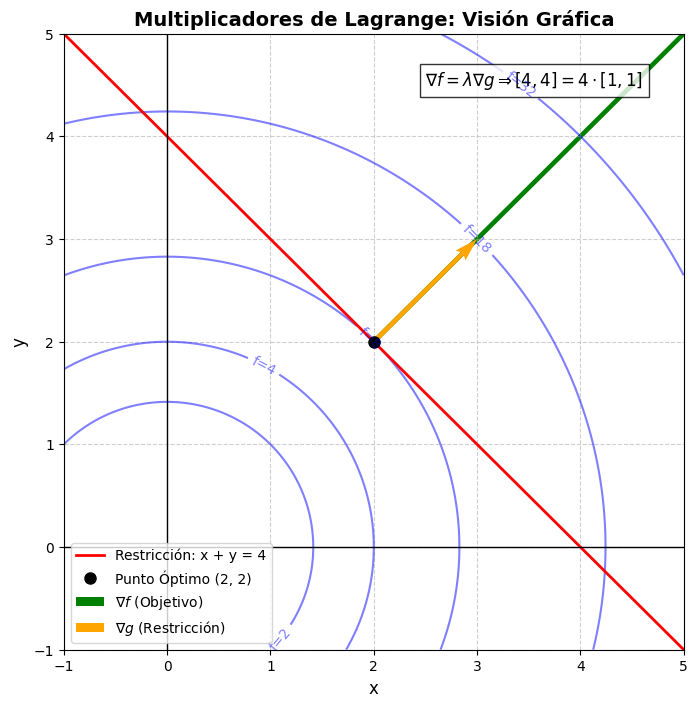

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear la grilla de puntos para el gráfico
x = np.linspace(-1, 5, 400)
y = np.linspace(-1, 5, 400)
X, Y = np.meshgrid(x, y)

# 2. Función Objetivo (Curvas de nivel: x^2 + y^2)
Z = X**2 + Y**2

# 3. Preparar el gráfico
plt.figure(figsize=(8, 8))

# Dibujar las curvas de nivel (los círculos)
niveles = [2, 4, 8, 18, 32] # Diferentes valores para x^2 + y^2
cp = plt.contour(X, Y, Z, levels=niveles, colors='blue', alpha=0.5)
plt.clabel(cp, inline=True, fontsize=10, fmt="f=%1.0f")

# 4. Dibujar la restricción g(x,y) = x + y = 4
# Despejamos y: y = 4 - x
y_restriccion = 4 - x
plt.plot(x, y_restriccion, color='red', linewidth=2, label='Restricción: x + y = 4')

# 5. Marcar el punto óptimo (Tangencia en x=2, y=2)
x_opt, y_opt = 2, 2
plt.plot(x_opt, y_opt, 'ko', markersize=8, label='Punto Óptimo (2, 2)')

# 6. Dibujar los Vectores Gradiente para mostrar Lambda
# Gradiente de f en (2,2) es [2x, 2y] = [4, 4]
# Gradiente de g en (2,2) es [1, 1]
# Dibujamos las flechas partiendo del punto óptimo
plt.quiver(x_opt, y_opt, 4, 4, color='green', angles='xy', scale_units='xy', scale=1, label=r'$\nabla f$ (Objetivo)')
plt.quiver(x_opt, y_opt, 1, 1, color='orange', angles='xy', scale_units='xy', scale=1, label=r'$\nabla g$ (Restricción)')

# Añadir texto explicativo para Lambda
plt.text(2.5, 4.5, r'$\nabla f = \lambda \nabla g \Rightarrow [4,4] = 4 \cdot [1,1]$', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# 7. Configuración final del gráfico
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Multiplicadores de Lagrange: Visión Gráfica', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(loc='lower left')

# Mostrar el gráfico
plt.show()

### Resolución en Python

In [2]:
from scipy.optimize import minimize

def objetivo(x):
    return x[0]**2 + x[1]**2

restricciones = [
    {'type': 'eq', 'fun': lambda x: x[0] + x[1] - 4}
]

x0 = [0, 0]
res = minimize(objetivo, x0, method='SLSQP', constraints=restricciones)

print('--- EJEMPLO 1: DISTANCIA AL ORIGEN ---')
if res.success:
    x_opt, y_opt = res.x
    print(f'x optimo: {x_opt:.4f}')
    print(f'y optimo: {y_opt:.4f}')
    print(f'Valor objetivo: {res.fun:.4f}')
else:
    print('Error:', res.message)

--- EJEMPLO 1: DISTANCIA AL ORIGEN ---
x optimo: 2.0000
y optimo: 2.0000
Valor objetivo: 8.0000


## Ejemplo 2: sinergia perfecta (reloj inteligente)

Maximizar $f(x,y) = xy$ sujeto a $x^2 + y^2 = 1$.

### Visualización

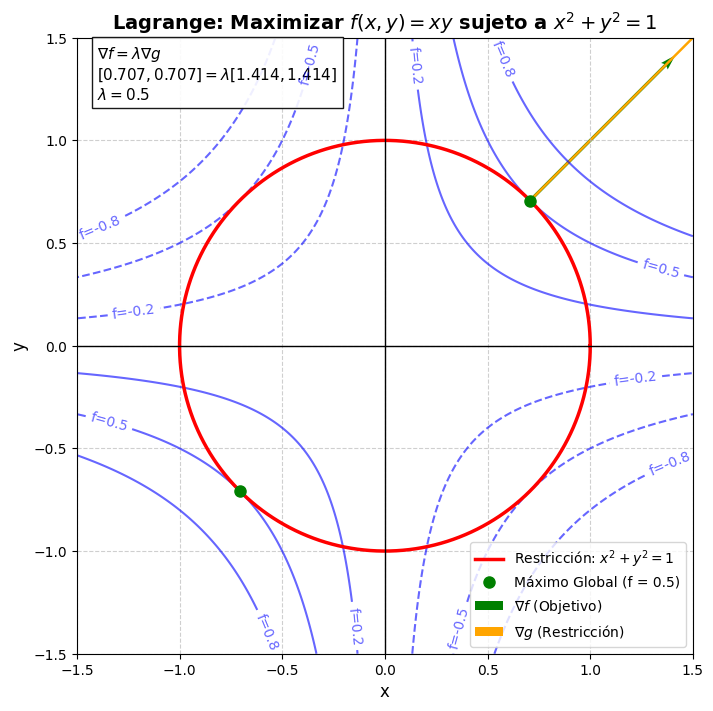

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear la grilla de puntos (espacio de -1.5 a 1.5)
x = np.linspace(-1.5, 1.5, 400)
y = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x, y)

# 2. Función Objetivo (Curvas de nivel: Z = X * Y)
Z = X * Y

# 3. Preparar el gráfico
plt.figure(figsize=(8, 8))

# Dibujar las curvas de nivel (las hipérbolas)
# Elegimos niveles específicos para que se vea claro cómo se acercan al círculo
niveles = [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]
cp = plt.contour(X, Y, Z, levels=niveles, colors='blue', alpha=0.6)
plt.clabel(cp, inline=True, fontsize=10, fmt="f=%1.1f")

# 4. Dibujar la restricción g(x,y) = x^2 + y^2 = 1 (El círculo)
# Usamos parámetros de ángulo (theta) para dibujar un círculo perfecto
theta = np.linspace(0, 2*np.pi, 200)
x_circ = np.cos(theta)
y_circ = np.sin(theta)
plt.plot(x_circ, y_circ, color='red', linewidth=2.5, label=r'Restricción: $x^2 + y^2 = 1$')

# 5. Marcar los Puntos Óptimos
# Hay dos máximos (cuadrantes 1 y 3) y dos mínimos (cuadrantes 2 y 4)
x_opt = np.sqrt(2)/2  # ~0.707
y_opt = np.sqrt(2)/2  # ~0.707
plt.plot(x_opt, y_opt, 'go', markersize=8, label='Máximo Global (f = 0.5)')
plt.plot(-x_opt, -y_opt, 'go', markersize=8) # El otro máximo en el 3er cuadrante

# 6. Dibujar los Vectores Gradiente en el punto del 1er cuadrante
# Gradiente de f (xy) -> [y, x] = [0.707, 0.707]
# Gradiente de g (x^2+y^2) -> [2x, 2y] = [1.414, 1.414]
plt.quiver(x_opt, y_opt, x_opt, x_opt, color='green', angles='xy', scale_units='xy', scale=1,
           width=0.005, label=r'$\nabla f$ (Objetivo)')
plt.quiver(x_opt, y_opt, 2*x_opt, 2*x_opt, color='orange', angles='xy', scale_units='xy', scale=1,
           width=0.004, label=r'$\nabla g$ (Restricción)')

# Añadir texto explicativo para Lambda en el gráfico
plt.text(-1.4, 1.2, r'$\nabla f = \lambda \nabla g$' + '\n' + r'$[0.707, 0.707] = \lambda [1.414, 1.414]$' + '\n' + r'$\lambda = 0.5$',
         fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

# 7. Configuración final del gráfico
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title(r'Lagrange: Maximizar $f(x,y) = xy$ sujeto a $x^2+y^2=1$', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(loc='lower right')
plt.gca().set_aspect('equal', adjustable='box') # Para que el círculo no se vea ovalado

# Mostrar el gráfico
plt.show()

### Resolución en Python

In [4]:
import numpy as np
from scipy.optimize import minimize

# Minimizamos el negativo para maximizar
def objetivo_neg(x):
    return -x[0] * x[1]

restricciones = [
    {'type': 'eq', 'fun': lambda x: x[0]**2 + x[1]**2 - 1}
]

# Arrancamos en el cuadrante positivo para quedarnos con el maximo
x0 = [0.5, 0.5]
res = minimize(objetivo_neg, x0, method='SLSQP', constraints=restricciones)

print('--- EJEMPLO 2: RELOJ INTELIGENTE ---')
if res.success:
    x_opt, y_opt = res.x
    print(f'x optimo (bateria): {x_opt:.4f}')
    print(f'y optimo (pantalla): {y_opt:.4f}')
    print(f'Sinergia maxima: {-res.fun:.4f}')
else:
    print('Error:', res.message)

--- EJEMPLO 2: RELOJ INTELIGENTE ---
x optimo (bateria): 0.7071
y optimo (pantalla): 0.7071
Sinergia maxima: 0.5000


## Ejemplo 3: producción Cobb-Douglas

Maximizar $P(L, K) = 10 L^{0.5} K^{0.5}$ sujeto a $20L + 50K = 1000$.

### Resolución en Python

In [5]:
import numpy as np
from scipy.optimize import minimize

# 1. Función Objetivo (SciPy siempre minimiza, así que multiplicamos por -1 para maximizar)
def produccion(x):
    L, K = x[0], x[1]
    # P(L, K) = 10 * L^0.5 * K^0.5
    return -(10 * np.sqrt(L) * np.sqrt(K))

# 2. Restricción de Igualdad: 20L + 50K = 1000
# En SciPy, las restricciones se igualan a cero: 1000 - (20L + 50K) = 0
def restriccion_presupuesto(x):
    L, K = x[0], x[1]
    return 1000 - (20 * L + 50 * K)

restricciones = {'type': 'eq', 'fun': restriccion_presupuesto}
limites = ((0, None), (0, None)) # No podemos tener horas negativas
x0 = [10, 10] # Semilla inicial

# 3. Resolver
res = minimize(produccion, x0, method='SLSQP', bounds=limites, constraints=restricciones)

print("--- EJEMPLO 3: COBB-DOUGLAS ---")
print(f"Horas de Trabajo (L) óptimas: {res.x[0]:.2f}")
print(f"Horas de Máquina (K) óptimas: {res.x[1]:.2f}")
print(f"Producción Máxima: {-res.fun:.2f} unidades")

--- EJEMPLO 3: COBB-DOUGLAS ---
Horas de Trabajo (L) óptimas: 25.00
Horas de Máquina (K) óptimas: 10.00
Producción Máxima: 158.11 unidades


## Ejemplo 4: Hardware y Software con sinergia

Maximizar $B(x,y) = 50x - 0.5x^2 + 40y - y^2 + xy$ sujeto a $x + 2y = 80$.

### Visualización y resolución

--- Resultado de la Optimización ---
Hardware (x): 44.00
Software (y): 18.00
Beneficio Máximo: 2420.00


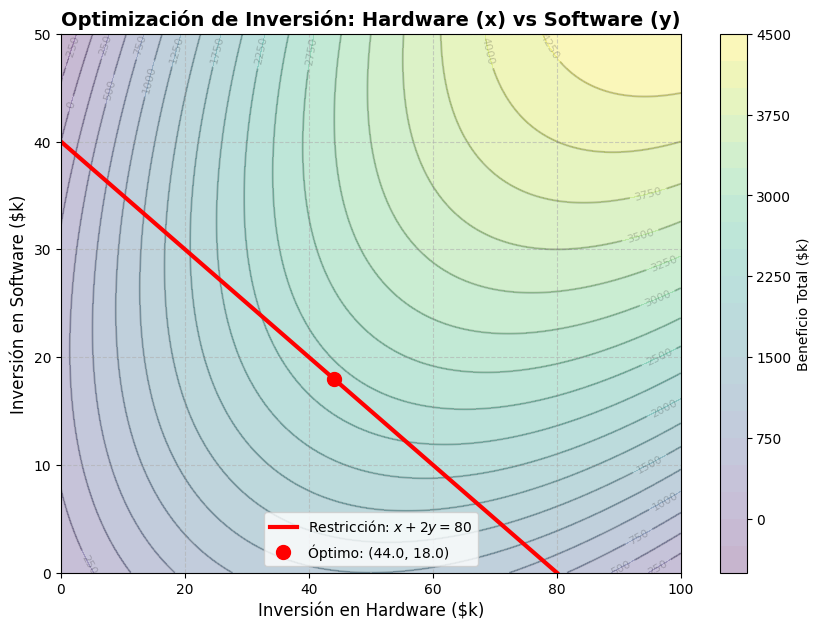

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Definir la Función de Beneficios (Objetivo)
# Queremos MAXIMIZAR B(x, y) = 50x - 0.5x^2 + 40y - y^2 + xy
# Como SciPy minimiza, retornamos el valor negativo.
def beneficio_objetivo(vars):
    x, y = vars
    B = 50*x - 0.5*x**2 + 40*y - y**2 + x*y
    return -B

# 2. Definir la Restricción de Presupuesto (x + 2y = 80 -> x + 2y - 80 = 0)
def presupuesto_restriccion(vars):
    x, y = vars
    return x + 2*y - 80

# Configuración de la restricción para el solver
cons = {'type': 'eq', 'fun': presupuesto_restriccion}

# 3. Punto inicial de búsqueda (arbitrario)
x0 = [10, 10]

# 4. Ejecutar la optimización
resultado = minimize(beneficio_objetivo, x0, constraints=cons, method='SLSQP')
x_opt, y_opt = resultado.x

# --- PARTE GRÁFICA ---

# Crear la grilla de puntos para el mapa de calor/curvas de nivel
x_range = np.linspace(0, 100, 400)
y_range = np.linspace(0, 50, 400)
X, Y = np.meshgrid(x_range, y_range)

# Calcular el beneficio en toda la grilla
Z = 50*X - 0.5*X**2 + 40*Y - Y**2 + X*Y

plt.figure(figsize=(10, 7))

# Dibujar las curvas de nivel del Beneficio
# El color indica la altura (mientras más claro/amarillo, más beneficio)
cp = plt.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.3)
plt.colorbar(cp, label='Beneficio Total ($k)')
contours = plt.contour(X, Y, Z, levels=20, colors='black', alpha=0.2)
plt.clabel(contours, inline=True, fontsize=8)

# Dibujar la línea de restricción presupuestaria (x + 2y = 80 -> y = (80 - x)/2)
x_line = np.linspace(0, 80, 100)
y_line = (80 - x_line) / 2
plt.plot(x_line, y_line, color='red', linewidth=3, label='Restricción: $x + 2y = 80$')

# Marcar el Punto Óptimo encontrado
plt.plot(x_opt, y_opt, 'ro', markersize=10, label=f'Óptimo: ({x_opt:.1f}, {y_opt:.1f})')

# Detalles estéticos
plt.title('Optimización de Inversión: Hardware (x) vs Software (y)', fontsize=14, fontweight='bold')
plt.xlabel('Inversión en Hardware ($k)', fontsize=12)
plt.ylabel('Inversión en Software ($k)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Mostrar resultados numéricos por consola
print("--- Resultado de la Optimización ---")
print(f"Hardware (x): {x_opt:.2f}")
print(f"Software (y): {y_opt:.2f}")
print(f"Beneficio Máximo: {-resultado.fun:.2f}")

plt.show()

## Ejemplo 5: Influencers vs TV (función cúbica)

Maximizar $V(x,y) = -\frac{1}{3}x^3 + 5x^2 - 11x + 5y$ sujeto a $x + y = 10$.

### Visualización y resolución

--- Resultados del Solver SLSQP ---
Optimización exitosa: True
Inversión Óptima en Influencers (x): 8.00
Inversión Óptima en TV (y): 2.00
Ventas Máximas Proyectadas: 71.33 millones


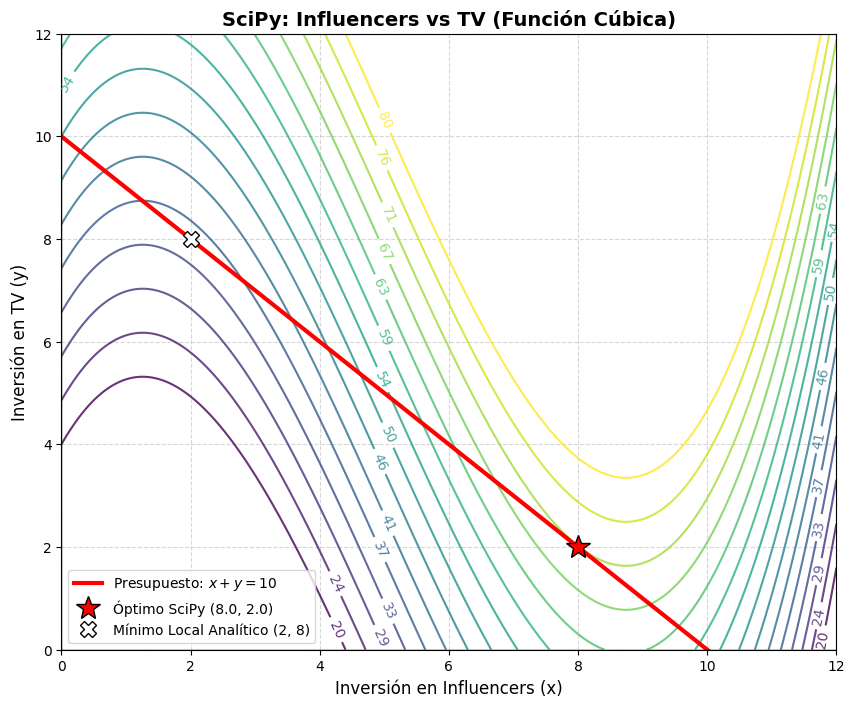

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Definir la Función Objetivo
# IMPORTANTE: SciPy por defecto solo MINIMIZA.
# Como queremos maximizar las ventas V(x,y), le pedimos que minimice -V(x,y).
def objetivo(vars):
    x, y = vars
    V = -(1/3)*x**3 + 5*x**2 - 11*x + 5*y
    return -V  # Multiplicamos por -1 para maximizar

# 2. Definir la Restricción de Igualdad (x + y = 10 -> x + y - 10 = 0)
def restriccion(vars):
    x, y = vars
    return x + y - 10

# SciPy requiere las restricciones en formato de diccionario
cons = {'type': 'eq', 'fun': restriccion}

# 3. Punto Inicial (El concepto clave de tu Diapositiva 2)
# Como la función es no lineal y tiene un valle, de dónde empezamos importa.
# Si ponemos x0 = [1, 9], SciPy caerá en el mínimo local (x=2).
# Empezamos en un punto razonable buscando el pico:
x0 = [7, 3]

# 4. Ejecutar el Algoritmo de Optimización (Sequential Least SQuares Programming)
resultado = minimize(objetivo, x0, constraints=cons, method='SLSQP')
x_opt, y_opt = resultado.x

# --- PARTE GRÁFICA ---

# Crear la grilla de puntos (acotado al presupuesto y un poco más)
x_vals = np.linspace(0, 12, 400)
y_vals = np.linspace(0, 12, 400)
X, Y = np.meshgrid(x_vals, y_vals)

# Evaluar Z (usamos la función original, sin invertir, para ver las ganancias reales)
Z = -(1/3)*X**3 + 5*X**2 - 11*X + 5*Y

plt.figure(figsize=(10, 8))

# Dibujar las curvas de nivel (isocuantas de beneficio)
niveles = np.linspace(20, 80, 15)
cp = plt.contour(X, Y, Z, levels=niveles, cmap='viridis', alpha=0.8)
plt.clabel(cp, inline=True, fontsize=10, fmt="%1.0f")

# Dibujar la restricción presupuestaria (y = 10 - x)
y_const = 10 - x_vals
plt.plot(x_vals, y_const, color='red', linewidth=3, label='Presupuesto: $x + y = 10$')

# Marcar el punto óptimo (Máximo) encontrado por SciPy
plt.plot(x_opt, y_opt, 'r*', markersize=18, markeredgecolor='black',
         label=f'Óptimo SciPy ({x_opt:.1f}, {y_opt:.1f})')

# Marcar el Mínimo Local para contrastar
plt.plot(2, 8, 'wX', markersize=12, markeredgecolor='black',
         label='Mínimo Local Analítico (2, 8)')

# Configuración final del gráfico
plt.xlim(0, 12)
plt.ylim(0, 12)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('SciPy: Influencers vs TV (Función Cúbica)', fontsize=14, fontweight='bold')
plt.xlabel('Inversión en Influencers (x)', fontsize=12)
plt.ylabel('Inversión en TV (y)', fontsize=12)
plt.legend(loc='lower left')

# Imprimir los resultados por consola
print("--- Resultados del Solver SLSQP ---")
print(f"Optimización exitosa: {resultado.success}")
print(f"Inversión Óptima en Influencers (x): {x_opt:.2f}")
print(f"Inversión Óptima en TV (y): {y_opt:.2f}")
# Volvemos a invertir el signo de la función objetivo para mostrar la ganancia real
print(f"Ventas Máximas Proyectadas: {-resultado.fun:.2f} millones")

plt.show()

# Condiciones KKT

A partir de acá entramos en problemas con restricciones de desigualdad.

## Ejemplo 6: capital y trabajo con dos restricciones (KKT)

Maximizar $B(x,y) = 10x - x^2 + 10y - y^2$ sujeto a $x + 2y \leq 14$, $2x + y \leq 14$.

### Visualización y resolución

--- Resultados del Solver ---
Producción Óptima de X: 4.67
Producción Óptima de Y: 4.67
Beneficio Máximo Alcanzado: 49.78


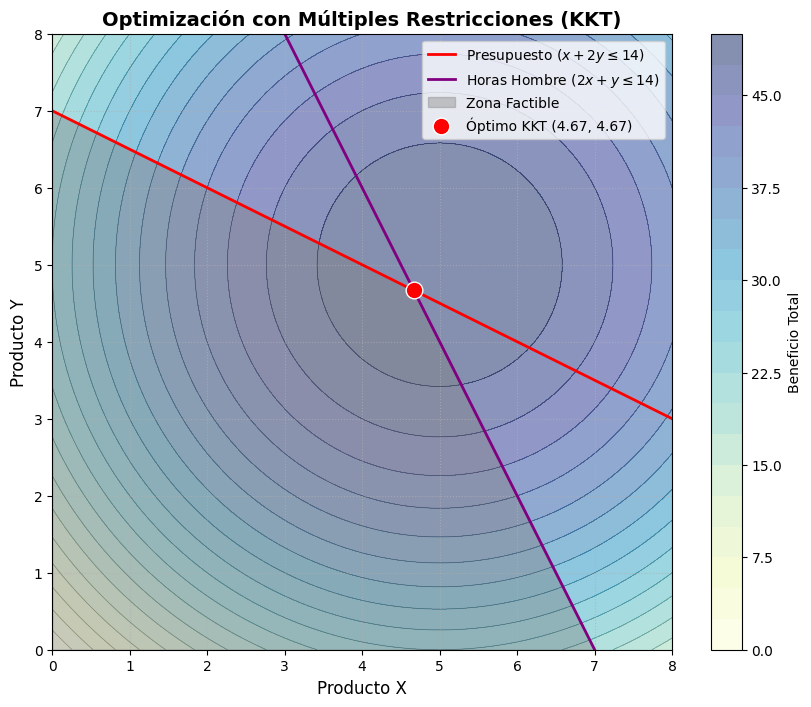

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Función Objetivo (Maximizamos Beneficio, así que minimizamos su negativo)
def beneficio(vars):
    x, y = vars
    B = 10*x - x**2 + 10*y - y**2
    return -B

# 2. Definir las DOS restricciones (KKT: Desigualdades >= 0)
# Para SciPy 'ineq' significa que la función debe ser Mayor o Igual a 0.
# x + 2y <= 14  -->  14 - x - 2y >= 0
def restriccion_presupuesto(vars):
    x, y = vars
    return 14 - x - 2*y

# 2x + y <= 14  -->  14 - 2x - y >= 0
def restriccion_horas(vars):
    x, y = vars
    return 14 - 2*x - y

# Diccionarios de restricciones para el solver
cons = (
    {'type': 'ineq', 'fun': restriccion_presupuesto},
    {'type': 'ineq', 'fun': restriccion_horas}
)

# Límites de no negatividad (x >= 0, y >= 0)
bounds = ((0, None), (0, None))

# 3. Punto de inicio y ejecución
x0 = [1, 1]
resultado = minimize(beneficio, x0, method='SLSQP', bounds=bounds, constraints=cons)
x_opt, y_opt = resultado.x

# --- PARTE GRÁFICA ---

# Preparar el lienzo
plt.figure(figsize=(10, 8))
x_vals = np.linspace(0, 10, 400)
y_vals = np.linspace(0, 10, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = 10*X - X**2 + 10*Y - Y**2

# Curvas de nivel
cp = plt.contourf(X, Y, Z, levels=20, cmap='YlGnBu', alpha=0.5)
plt.colorbar(cp, label='Beneficio Total')
plt.contour(X, Y, Z, levels=20, colors='black', alpha=0.3, linewidths=0.5)

# Las líneas de las restricciones
# Restricción 1: y = (14 - x) / 2
y_presupuesto = (14 - x_vals) / 2
plt.plot(x_vals, y_presupuesto, color='red', linewidth=2, label=r'Presupuesto ($x + 2y \leq 14$)')

# Restricción 2: y = 14 - 2x
y_horas = 14 - 2*x_vals
plt.plot(x_vals, y_horas, color='purple', linewidth=2, label=r'Horas Hombre ($2x + y \leq 14$)')

# SOMBREAR LA REGIÓN FACTIBLE
# Tomamos el mínimo entre ambas restricciones para delimitar el techo del polígono
y_limite_superior = np.minimum(y_presupuesto, y_horas)
# Rellenamos desde y=0 hasta el techo, asegurando que x no pase el límite
plt.fill_between(x_vals, 0, y_limite_superior, where=(y_limite_superior>=0),
                 color='gray', alpha=0.4, label='Zona Factible')

# Marcar el punto óptimo
plt.plot(x_opt, y_opt, 'ro', markersize=12, markeredgecolor='white',
         label=f'Óptimo KKT ({x_opt:.2f}, {y_opt:.2f})')

# Configuración final
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.xlabel('Producto X', fontsize=12)
plt.ylabel('Producto Y', fontsize=12)
plt.title('Optimización con Múltiples Restricciones (KKT)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right')

# Imprimir resultados
print("--- Resultados del Solver ---")
print(f"Producción Óptima de X: {x_opt:.2f}")
print(f"Producción Óptima de Y: {y_opt:.2f}")
print(f"Beneficio Máximo Alcanzado: {-resultado.fun:.2f}")

plt.show()

## Ejemplo 7: cuando una restricción sobra ($\mu$ negativo)

Minimizar $f(x, y) = x^2 + y^2$ sujeto a $x + y \leq 2$.

Si asumimos que la restricción está activa, al resolver obtenemos $\mu = -2 < 0$, que **viola factibilidad dual**. Entonces la descartamos y probamos con la restricción inactiva: el óptimo libre es $(0, 0)$ que cumple la restricción con holgura.

### Resolución en Python

In [9]:
import numpy as np
from scipy.optimize import minimize

def objetivo(v):
    return v[0]**2 + v[1]**2

# Restriccion x + y <= 2 -> en forma ineq de scipy: 2 - (x + y) >= 0
restricciones = [
    {'type': 'ineq', 'fun': lambda v: 2 - (v[0] + v[1])}
]

x0 = [1, 1]
res = minimize(objetivo, x0, method='SLSQP', constraints=restricciones)

print('--- EJEMPLO 7: RESTRICCION QUE SOBRA ---')
if res.success:
    x_opt, y_opt = res.x
    print(f'x optimo: {x_opt:.4f}')
    print(f'y optimo: {y_opt:.4f}')
    print(f'Valor objetivo: {res.fun:.4f}')
    suma = x_opt + y_opt
    print(f'x + y = {suma:.4f} (la restriccion x+y<=2 se cumple con holgura)')
else:
    print('Error:', res.message)

--- EJEMPLO 7: RESTRICCION QUE SOBRA ---
x optimo: 0.0000
y optimo: 0.0000
Valor objetivo: 0.0000
x + y = 0.0000 (la restriccion x+y<=2 se cumple con holgura)
